In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re


In [ ]:
# zapisywanie plotów do plików

FIG_DIR = Path("../plots/brca")

def make_filename(title: str, cohort: str = "brca", ext: str = "png"):
    """
    Zamienia tytuł wykresu na snake_case + suffix cohort
    """
    title = title.lower()
    title = re.sub(r"[^\w\s]", "", title)   # usuń znaki specjalne
    title = re.sub(r"\s+", "_", title)      # spacje -> _
    return f"{title}_{cohort}.{ext}"

def save_figure(
    fig,
    title: str,
    fig_dir: Path,
    cohort: str = "brca",
    formats: tuple = ("png",),
    dpi: int = 300,
    close: bool = True,
):
    """
    Zapisuje aktualną figurę matplotlib do pliku/plików.
    """

    fig_dir.mkdir(parents=True, exist_ok=True)
    for ext in formats:
        filename = make_filename(title, cohort, ext)
        fig.savefig(
            fig_dir / filename,
            dpi=dpi,
            bbox_inches="tight",
            facecolor="white"
        )

    if close:
        plt.close(fig)

In [3]:
# configuracja matplotliba

plt.rcParams.update({
    "figure.figsize": (6, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11
})

PINK = "#E9A6B5"
DARK_PINK = "#C75B7A"
WHITE = "#FFFFFF"


In [ ]:
# ładowanie danych

expr_df = pd.read_csv('../../data/0_data_for_mlp/TCGA-BRCA.star_tpm.csv')
# expr_df = pd.read_csv('../data/0_data_for_mlp/TCGA-BRCA.star_counts.csv').apply(pd.to_numeric, errors="coerce")
expr_df = expr_df.iloc[:, 1:]
values = expr_df.values.flatten()

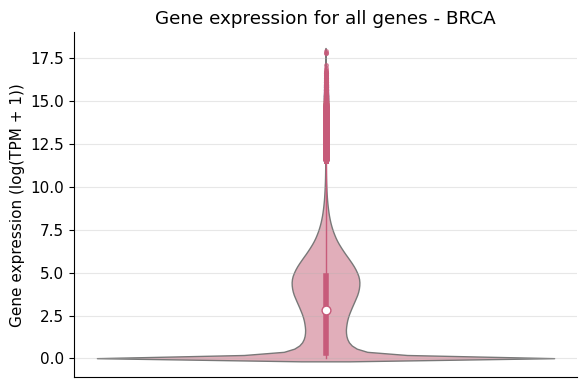

In [55]:
# ALL GENES VIOLIN PLOT

all_values = expr_df.values.flatten()
data = all_values

# statystyki
q1 = np.percentile(data, 25)
median = np.percentile(data, 50)
q3 = np.percentile(data, 75)
iqr = q3 - q1

lower_whisker = np.min(data[data >= q1 - 1.5 * iqr])
upper_whisker = np.max(data[data <= q3 + 1.5 * iqr])
outliers = data[(data < lower_whisker) | (data > upper_whisker)]

# figura
fig, ax = plt.subplots(figsize=(6, 4))

# violin
sns.violinplot(
    y=data,
    inner=None,
    color=PINK,
    linewidth=1,
    ax=ax
)

# thin line = min-max bez outlierów
ax.plot([0, 0], [lower_whisker, upper_whisker],
        color=DARK_PINK, linewidth=1, zorder=3)

# bold line = IQR
ax.plot([0, 0], [q1, q3],
        color=DARK_PINK, linewidth=4, zorder=4)

# mediana
ax.scatter(0, median,
           color=WHITE, edgecolor=DARK_PINK,
           s=40, zorder=5)

# outliery
ax.scatter(np.zeros(len(outliers)), outliers,
           color=DARK_PINK, s=7, alpha=0.6, zorder=6)

# etykiety
ax.set_xticks([])
ax.set_ylabel("Gene expression (log(TPM + 1))")
title = "Gene expression for all genes - BRCA"
ax.set_title(title)

plt.tight_layout()
plt.show()

save_figure(fig, "Gene expression for all genes", FIG_DIR)

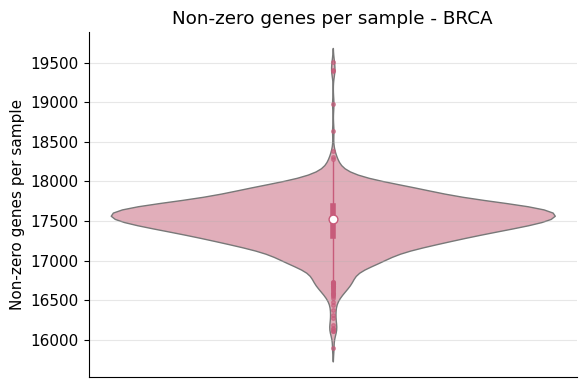

In [5]:
# NONE-ZERO GENES VIOLIN PLOT

nonzero_genes_per_sample = (expr_df > 0).sum(axis=1)
data = nonzero_genes_per_sample.values

# statystyki
q1 = np.percentile(data, 25)
median = np.percentile(data, 50)
q3 = np.percentile(data, 75)
iqr = q3 - q1

lower_whisker = np.min(data[data >= q1 - 1.5 * iqr])
upper_whisker = np.max(data[data <= q3 + 1.5 * iqr])

outliers = data[(data < lower_whisker) | (data > upper_whisker)]

fig, ax = plt.subplots()

# VIOLIN
sns.violinplot(
    y=data,
    inner=None,      # wyłączamy defaultowe statystyki
    color=PINK,
    linewidth=1,
    ax=ax
)

# CIENKA LINIA: min–max (bez outlierów)
ax.plot(
    [0, 0],
    [lower_whisker, upper_whisker],
    color=DARK_PINK,
    linewidth=1,
    zorder=3
)

# GRUBA LINIA: IQR
ax.plot(
    [0, 0],
    [q1, q3],
    color=DARK_PINK,
    linewidth=4,
    zorder=4
)

# BIAŁY PUNKT: mediana
ax.scatter(
    0,
    median,
    color=WHITE,
    edgecolor=DARK_PINK,
    zorder=5,
    s=40
)

# OUTLIERY
ax.scatter(
    np.zeros(len(outliers)),
    outliers,
    color=DARK_PINK,
    alpha=0.6,
    s=7,
    zorder=6
)

# estetyka
ax.set_xticks([])
ax.set_ylabel("Non-zero genes per sample")
ax.set_title("Non-zero genes per sample - BRCA")

plt.tight_layout()
plt.show()

save_figure(fig, "Non-zero genes per sample - BRCA", FIG_DIR)

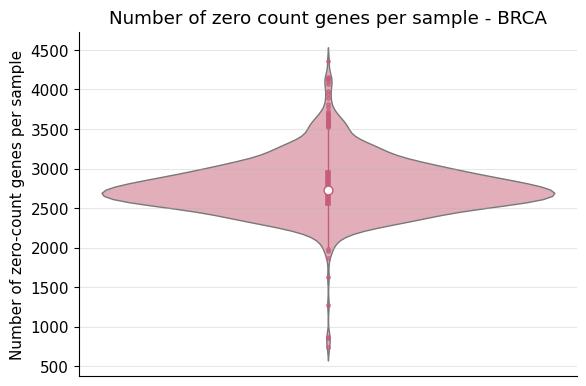

In [ ]:
# ZERO GENES VIOLIN PLOT

zero_genes_per_sample = (expr_df == 0).sum(axis=1)
data = zero_genes_per_sample.values

# statystyki boxplotowe
q1 = np.percentile(data, 25)
median = np.percentile(data, 50)
q3 = np.percentile(data, 75)
iqr = q3 - q1

lower_whisker = np.min(data[data >= q1 - 1.5 * iqr])
upper_whisker = np.max(data[data <= q3 + 1.5 * iqr])
outliers = data[(data < lower_whisker) | (data > upper_whisker)]

fig, ax = plt.subplots()

# violin
sns.violinplot(
    y=data,
    inner=None,
    color=PINK,
    linewidth=1,
    ax=ax
)

# min–max (bez outlierów)
ax.plot([0, 0], [lower_whisker, upper_whisker],
        color=DARK_PINK, linewidth=1, zorder=3)

# IQR
ax.plot([0, 0], [q1, q3],
        color=DARK_PINK, linewidth=4, zorder=4)

# mediana
ax.scatter(0, median,
           color=WHITE, edgecolor=DARK_PINK,
           s=60, zorder=5)

# outliery
ax.scatter(np.zeros(len(outliers)), outliers,
           color=DARK_PINK, s=7, alpha=0.6, zorder=6)

ax.set_xticks([])
ax.set_ylabel("Number of zero-count genes per sample")

title = "Number of zero count genes per sample - BRCA"
ax.set_title(title)
plt.tight_layout()
plt.show()
# zapis
save_figure(fig, "Zero genes per sample", FIG_DIR)


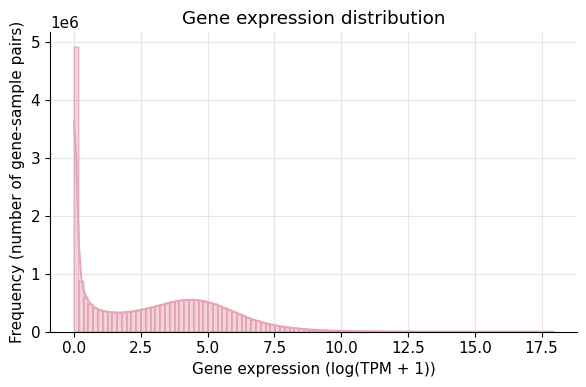

In [8]:
# GENE EXPRESSION DISTRIBUTION

fig, ax = plt.subplots()

sns.histplot(
    values,
    bins=100,
    stat="count",      # y = liczba obserwacji
    kde=True,          # gładka estymacja
    color=PINK,
    edgecolor=DARK_PINK,
    ax=ax
)

ax.set_xlabel("Gene expression (log(TPM + 1))")
ax.set_ylabel("Frequency (number of gene-sample pairs)")
ax.set_title("Gene expression distribution")

plt.tight_layout()
plt.show()

# zapis
save_figure(fig, "Gene expression distribution", FIG_DIR)


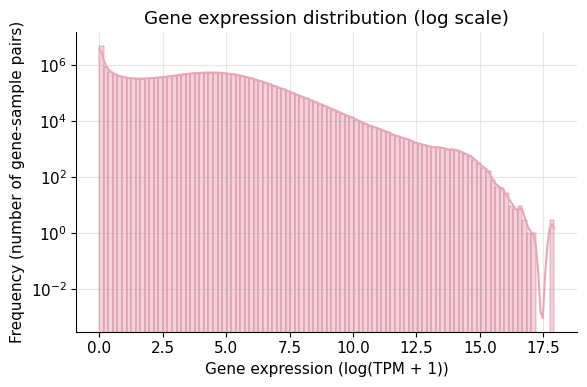

In [9]:
# GENE EXPRESSION DISTRIBUTION - LOG

fig, ax = plt.subplots()

sns.histplot(
    values,
    bins=100,
    stat="count",      # y = liczba obserwacji
    kde=True,          # gładka estymacja
    color=PINK,
    edgecolor=DARK_PINK,
    ax=ax
)

ax.set_xlabel("Gene expression (log(TPM + 1))")
ax.set_ylabel("Frequency (number of gene-sample pairs)")
ax.set_title("Gene expression distribution (log scale)")

ax.set_yscale("log")

plt.tight_layout()
plt.show()

# zapis
save_figure(fig, "Gene expression distribution log scale", FIG_DIR)


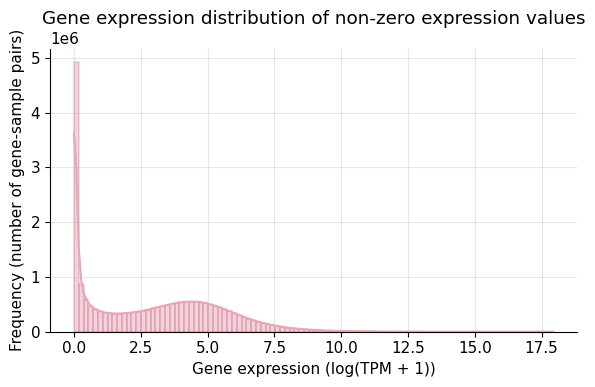

In [10]:
# GENE EXPRESSION DISTRIBUTION - NON - ZERO VALUES

nonzero_values = values[values > 0]


fig, ax = plt.subplots()

sns.histplot(
    values,
    bins=100,
    stat="count",      # y = liczba obserwacji
    kde=True,          # gładka estymacja
    color=PINK,
    edgecolor=DARK_PINK,
    ax=ax
)

ax.set_xlabel("Gene expression (log(TPM + 1))")
ax.set_ylabel("Frequency (number of gene-sample pairs)")
ax.set_title("Gene expression distribution of non-zero expression values")

plt.tight_layout()
plt.show()

# zapis
save_figure(fig, "Gene expression distribution of non-zero expression values", FIG_DIR)


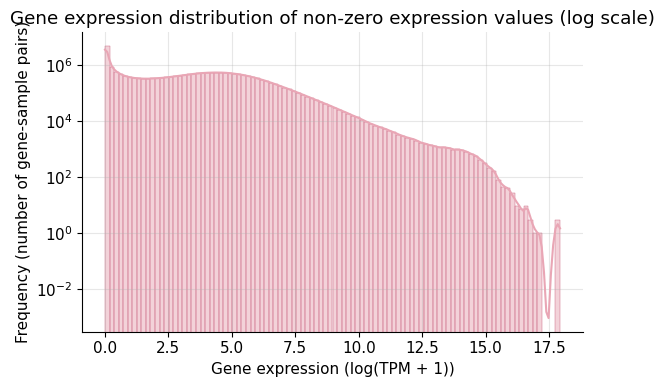

In [11]:
# GENE EXPRESSION DISTRIBUTION - NON - ZERO VALUES - LOG

nonzero_values = values[values > 0]


fig, ax = plt.subplots()

sns.histplot(
    values,
    bins=100,
    stat="count",      # y = liczba obserwacji
    kde=True,          # gładka estymacja
    color=PINK,
    edgecolor=DARK_PINK,
    ax=ax
)

ax.set_xlabel("Gene expression (log(TPM + 1))")
ax.set_ylabel("Frequency (number of gene-sample pairs)")
ax.set_title("Gene expression distribution of non-zero expression values (log scale)")

ax.set_yscale("log")

plt.tight_layout()
plt.show()

# zapis
save_figure(fig, "Gene expression distribution of non-zero expression values log scale", FIG_DIR)


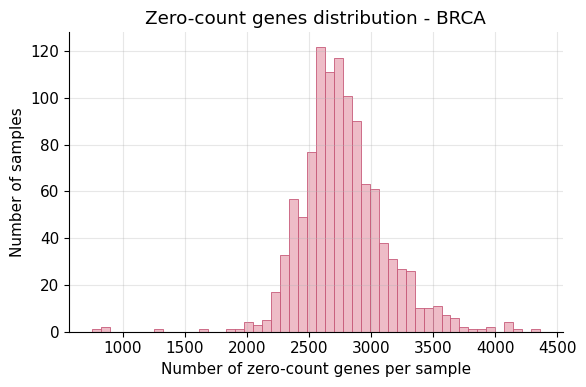

In [23]:
# ZERO GENES HIST PLOT

data = zero_genes_per_sample.values

fig, ax = plt.subplots()

sns.histplot(
    data,
    bins=50,
    color=PINK,
    edgecolor=DARK_PINK,
    stat="count",
    kde=False,
    ax=ax
)

ax.set_xlabel("Number of zero-count genes per sample")
ax.set_ylabel("Number of samples")
ax.set_title("Zero-count genes distribution - BRCA")

plt.tight_layout()
plt.show()

save_figure(fig, "Zero-count genes distribution - hist", FIG_DIR)


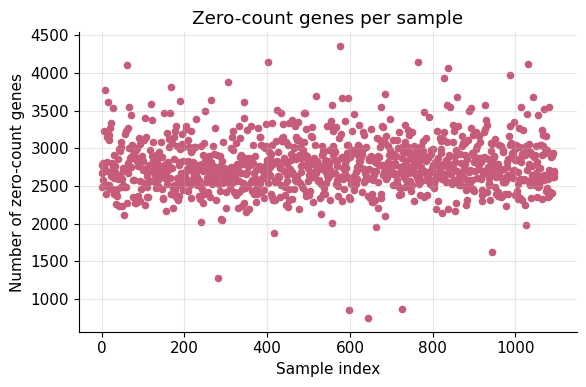

In [24]:
# ZERO GENES SCATTER PLOT

fig, ax = plt.subplots()

ax.scatter(
    range(len(data)),  # każda próbka po kolei
    data,
    color=DARK_PINK,
    s=20
)

ax.set_xlabel("Sample index")
ax.set_ylabel("Number of zero-count genes")
ax.set_title("Zero-count genes per sample")

plt.tight_layout()
plt.show()

save_figure(fig, "Zero-count genes distribution - scatter", FIG_DIR)


In [48]:
# HIGHLY VARIABLE GENES - data prep

top_n = 6000

# wariancja po genach
gene_variance = expr_df.var(axis=0)  

# możemy też użyć CV, jeśli chcesz porównywać między genami o różnych średnich
gene_mean = expr_df.mean(axis=0)
gene_cv = (expr_df.std(axis=0) / gene_mean).replace([np.inf, np.nan], 0)


hvg_genes = gene_variance.sort_values(ascending=False).head(top_n).index

# ekstrakcja danych HVG
hvg_data = expr_df[hvg_genes]
hvg_values = hvg_data.values.flatten()

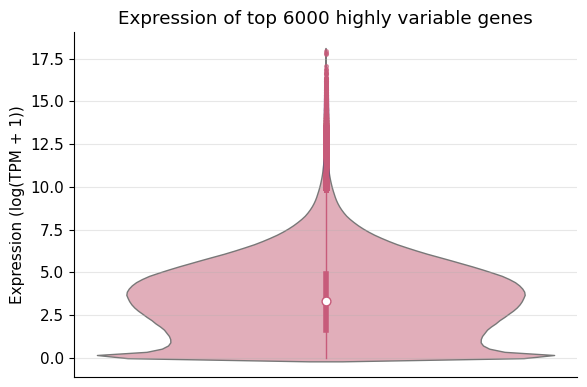

In [38]:
# HIGHLY VARIABLE GENES VIOLIN PLOT

data = hvg_values

# statystyki do overlay box
q1 = np.percentile(data, 25)
median = np.percentile(data, 50)
q3 = np.percentile(data, 75)
iqr = q3 - q1
lower_whisker = np.min(data[data >= q1 - 1.5 * iqr])
upper_whisker = np.max(data[data <= q3 + 1.5 * iqr])
outliers = data[(data < lower_whisker) | (data > upper_whisker)]

fig, ax = plt.subplots()

# violin
sns.violinplot(
    y=data,
    inner=None,
    color=PINK,
    linewidth=1,
    ax=ax
)

# thin line = min-max bez outlierów
ax.plot([0, 0], [lower_whisker, upper_whisker],
        color=DARK_PINK, linewidth=1, zorder=3)

# bold line = IQR
ax.plot([0, 0], [q1, q3],
        color=DARK_PINK, linewidth=4, zorder=4)

# mediana
ax.scatter(0, median,
           color=WHITE, edgecolor=DARK_PINK,
           s=40, zorder=5)

# outliery
ax.scatter(np.zeros(len(outliers)), outliers,
           color=DARK_PINK, s=7, alpha=0.6, zorder=6)

ax.set_xticks([])
ax.set_ylabel("Expression (log(TPM + 1))")
title = f"Expression of top {top_n} highly variable genes"
ax.set_title(title)

plt.tight_layout()
plt.show()

save_figure(fig, f"{top_n} highly variable genes - violin", FIG_DIR)


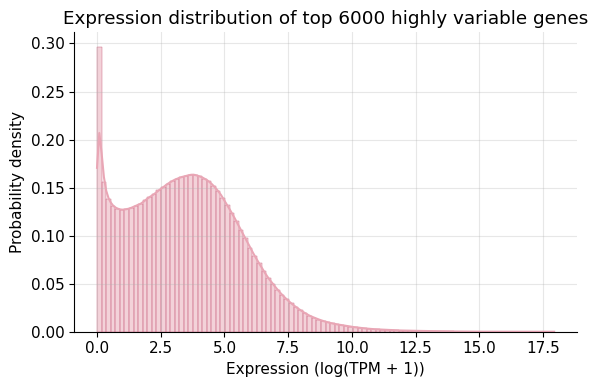

In [49]:
# HIGHLY VARIABLE GENES HIST PLOT
normalize = True

y_label = "Frequency (number of gene-sample pairs)"
stat = "count"
option = None

if normalize:
    y_label = y_label = "Probability density"
    stat = "density"
    option = "_normalized"

fig, ax = plt.subplots()

sns.histplot(
    hvg_values,
    bins=100,
    stat=stat,   # "density" or "count"; y = liczba obserwacji
    kde=True,       # gładka estymacja
    color=PINK,
    edgecolor=DARK_PINK,
    ax=ax
)

ax.set_xlabel("Expression (log(TPM + 1))")
ax.set_ylabel(y_label)
title = f"Expression distribution of top {top_n} highly variable genes"
ax.set_title(title)

plt.tight_layout()
plt.show()

save_figure(fig, f"{top_n} highly variable genes - hist{option}", FIG_DIR)


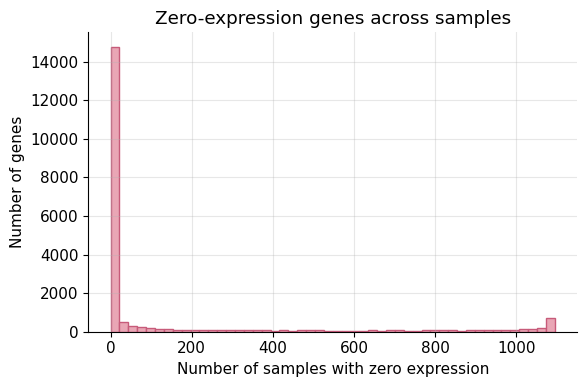

In [35]:
zero_per_gene = (expr_df == 0).sum(axis=0)

plt.hist(zero_per_gene, bins=50, color=PINK, edgecolor=DARK_PINK)
plt.xlabel("Number of samples with zero expression")
plt.ylabel("Number of genes")
plt.title("Zero-expression genes across samples")
plt.tight_layout()
plt.show()

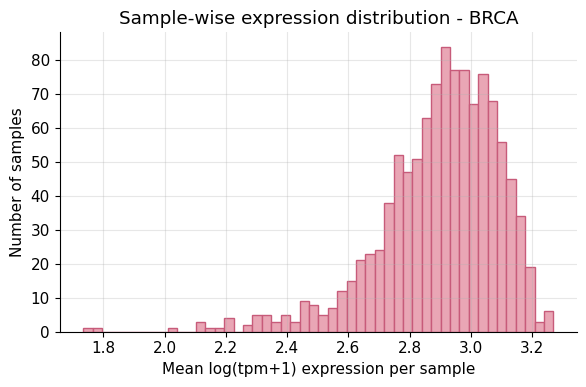

In [52]:
# PER SAMPLE MEAN

sample_means = expr_df.mean(axis=1)

# tworzymy figure i ax
fig, ax = plt.subplots()

# histogram
ax.hist(sample_means, bins=50, color=PINK, edgecolor=DARK_PINK)

# opisy osi i tytuł
ax.set_xlabel("Mean log(tpm+1) expression per sample")
ax.set_ylabel("Number of samples")
title = "Sample-wise expression distribution - BRCA"
ax.set_title(title)

plt.tight_layout()
plt.show()

save_figure(fig, "Sample-wise expression distribution", FIG_DIR)


idk co jest nizej

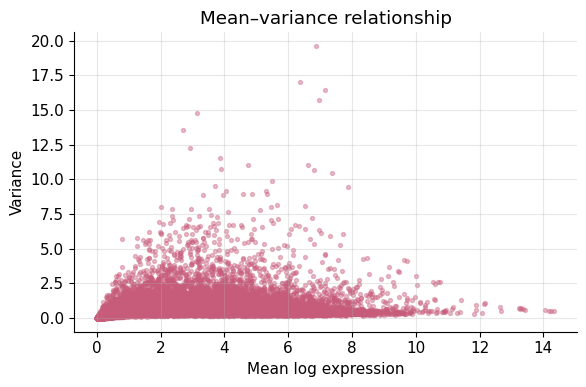

In [37]:
gene_mean = expr_df.mean(axis=0)
gene_var = expr_df.var(axis=0)

plt.scatter(
    gene_mean, gene_var,
    s=8, alpha=0.4, color=DARK_PINK
)
plt.xlabel("Mean log expression")
plt.ylabel("Variance")
plt.title("Mean–variance relationship")
plt.tight_layout()
plt.show()

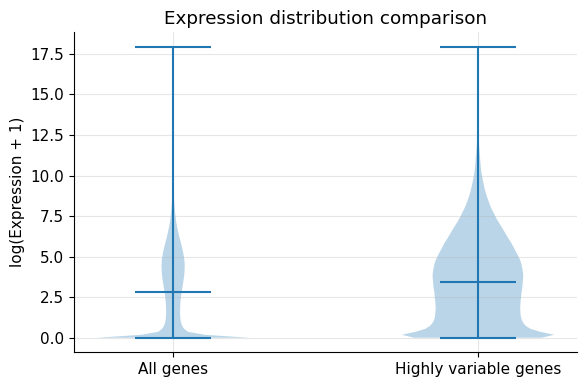

In [38]:
top_hvg = gene_var.sort_values(ascending=False).head(1000).index

all_vals = expr_df.values.flatten()
hvg_vals = expr_df[top_hvg].values.flatten()

plt.violinplot(
    [all_vals, hvg_vals],
    showmedians=True
)
plt.xticks([1, 2], ["All genes", "Highly variable genes"])
plt.ylabel("log(Expression + 1)")
plt.title("Expression distribution comparison")
plt.tight_layout()
plt.show()

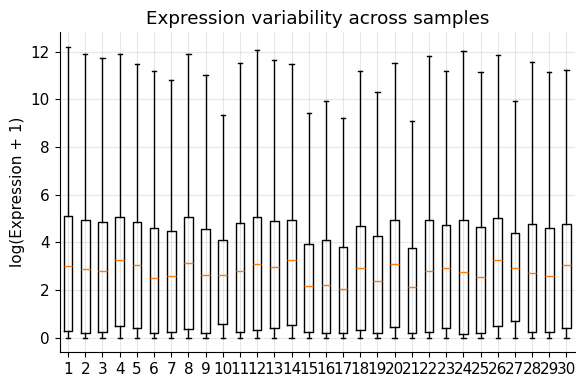

In [39]:
plt.boxplot(
    expr_df.sample(30, axis=0).T,  # losowe 30 genów
    showfliers=False
)
plt.ylabel("log(Expression + 1)")
plt.title("Expression variability across samples")
plt.tight_layout()
plt.show()

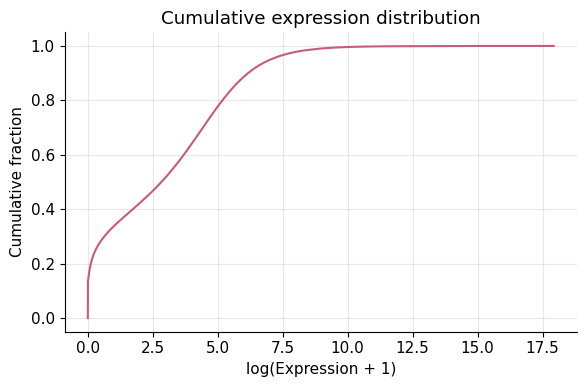

In [40]:
sorted_vals = np.sort(vals)
cdf = np.arange(len(sorted_vals)) / len(sorted_vals)

plt.plot(sorted_vals, cdf, color=DARK_PINK)
plt.xlabel("log(Expression + 1)")
plt.ylabel("Cumulative fraction")
plt.title("Cumulative expression distribution")
plt.tight_layout()
plt.show()

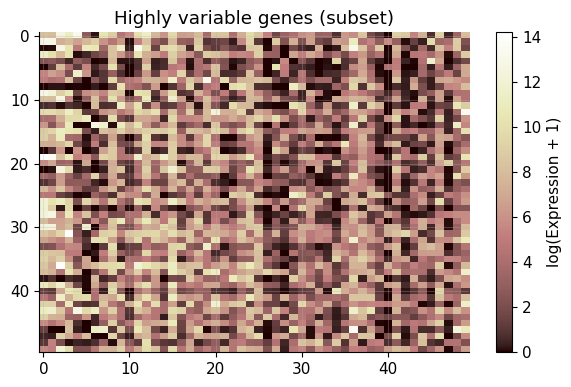

In [41]:
hvg_expr = expr_df[top_hvg].iloc[:50, :50]  # mały wycinek

plt.imshow(hvg_expr, aspect="auto", cmap="pink")
plt.colorbar(label="log(Expression + 1)")
plt.title("Highly variable genes (subset)")
plt.tight_layout()
plt.show()

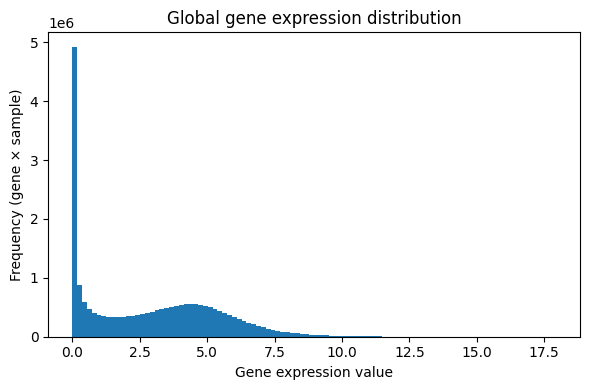

In [17]:
plt.figure(figsize=(6, 4))
plt.hist(values, bins=100)
# plt.yscale("log")
plt.xlabel("Gene expression value")
plt.ylabel("Frequency (gene × sample)")
plt.title("Global gene expression distribution")
plt.tight_layout()
plt.show()

In [18]:
n_zero = (values == 0).sum()
n_total = values.size

print(f"Zero values: {n_zero} / {n_total} ({n_zero / n_total:.2%})")
zero_per_gene = (expr_df == 0).sum(axis=0)

Zero values: 3033667 / 22184700 (13.67%)


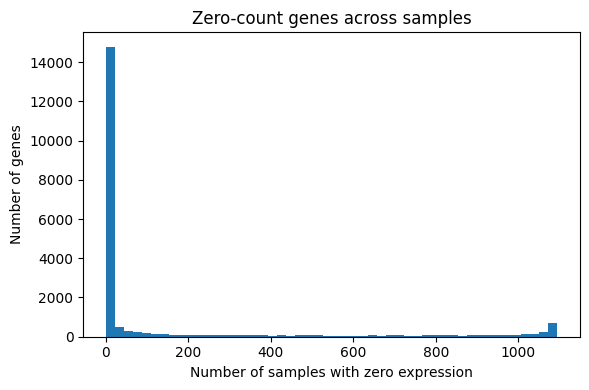

In [19]:
plt.figure(figsize=(6, 4))
plt.hist(zero_per_gene, bins=50)
plt.xlabel("Number of samples with zero expression")
plt.ylabel("Number of genes")
plt.title("Zero-count genes across samples")
plt.tight_layout()
plt.show()

In [20]:
gene_var = expr_df.var(axis=0)

In [21]:
top_hvg = gene_var.sort_values(ascending=False).head(1000).index

In [22]:
all_genes_vals = expr_df.values.flatten()
hvg_vals = expr_df[top_hvg].values.flatten()

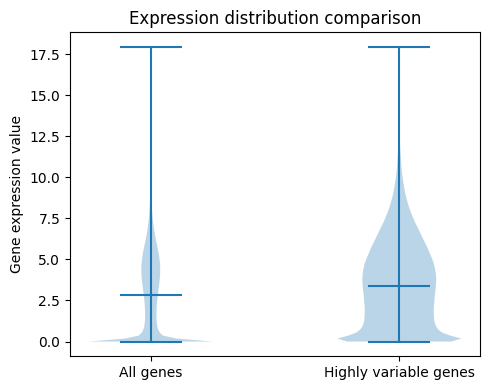

In [23]:
plt.figure(figsize=(5, 4))
plt.violinplot(
    [all_genes_vals, hvg_vals],
    showmeans=False,
    showmedians=True
)
plt.xticks([1, 2], ["All genes", "Highly variable genes"])
plt.ylabel("Gene expression value")
plt.title("Expression distribution comparison")
plt.tight_layout()
plt.show()

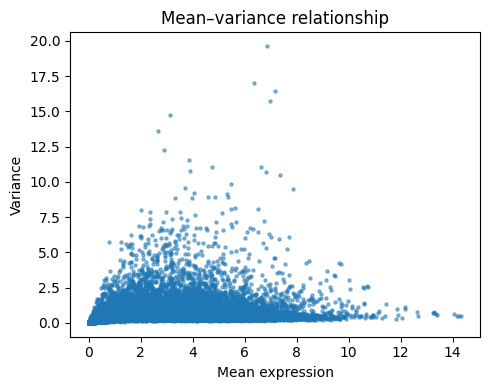

In [24]:
gene_mean = expr_df.mean(axis=0)

plt.figure(figsize=(5, 4))
plt.scatter(gene_mean, gene_var, s=5, alpha=0.5)
plt.xlabel("Mean expression")
plt.ylabel("Variance")
plt.title("Mean–variance relationship")
plt.tight_layout()
plt.show()